In [30]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field 
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
import operator
load_dotenv()

True

In [31]:
# We need three different types of llm based on task. 
# For generator llm -> Which are good at writing content
# For evaulator llm -> Based on given criteria, they can evaluate content (You should know about LLM providers.)
# For structured output llm -> LLMs which can give structured output like JSON, XML etc.

In [32]:
llm_model = "llama-3.1-8b-instant"
llm = ChatGroq(
    model=llm_model,
    temperature=0,
)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1188f3ee0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1188f37f0>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [33]:
class TweetEvaluation(BaseModel): 
    evaluation: Literal["approved", "need_improvement"] = Field(description="Final evaluation result.")
    feedback: str = Field(description="Constructive feedback for the tweet.")
    
    

In [34]:
structure_evaluator_llm = llm.with_structured_output(TweetEvaluation)

In [35]:
# Before moving forward, we need to define our state. 
class TweetState(TypedDict):
    topic: str 
    tweet: str 
    evalution: Literal["approved", "need_improvement"]
    feedback: str 
    iteration: int 
    max_iterations: int
    
    tweet_history:  Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [36]:
graph = StateGraph(TweetState)

In [37]:
def generate_tweet(state: TweetState) -> TweetState: 
    # First we need to get the topic from the state 
    topic = state['topic']
    # Draft a prompt based on what kind of tweet we want to generate 
    messages = [
        SystemMessage(content="You are a funny and cleaver Twitter/X influencer. You create engaging and witty tweets that captivate your audience."), 
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{topic}". 
        
        Rules: 
        DO NOT use question-answer format. 
        Max 280 characters. 
        User observational humor, irnoy, sarcasm, or cultural references. 
        Think in mem logic, punchlines, or relatable takes. 
        Use simple, day to day English. 
                     """)
    ]
    
    # Call the model 
    content = llm(messages).content
    
    # Update and reutrn it in state. 
    return {
        'tweet': content, 
        'tweet_history': [content]
    }
    
    

def evaluate_tweet(state: TweetState) -> TweetState: 
    
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."), 
        HumanMessage(content=f"""
        Evaluate the following tweet: 
        
        Tweet: "{state['tweet']}"
        
        Use the criteria below to evaluate the tweet: 
        
        1. Originality - Is this fresh, or have you seen it hundreds times before? 
        2. Humor - Did it genuinely make you laugh, smile or chuckle? 
        3. Punchlines - Is it short, sharp and scroll-stopping?
        4. Virality Potential - Would people retweet, like, or share it? 
        5. Format - Is it well-format tweet (not a setup-punchline joke, not a Q&A joke, and under 280 character)?
                     
        Auto-reject if: 
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters. 
        - It reads like a traditional setup-puncline joke 
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    content = structure_evaluator_llm.invoke(messages)

    
    return {
        'evalution': content.evaluation,
        'feedback': content.feedback, 
        'feedback_history': [content.feedback]
        
    }
    


def improve_tweet(state: TweetState) -> TweetState: 
    
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the following tweet based on the given feedback. 
        "{state['tweet']}"
        
        Topic: "{state['topic']}" 
        Original Tweet:
        {state['tweet']}
        
        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters. 
                     
                     """)
    ]
    response = llm(messages).content
    iteration = state['iteration'] + 1 
    
    return {
        'tweet': response, 
        'iteration': iteration, 
        'tweet_history': response
    }


In [38]:
def route_evaluation(state: TweetState):
    if state['evalution'] == "approved": 
        return "approved"
    elif state['iteration'] >= state['max_iterations']:
        return "approved"
    else: 
        return "need_improvement"

In [39]:
graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('improve', improve_tweet)


graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {
    'approved': END, 
    'need_improvement': 'improve'
})
graph.add_edge('improve', 'evaluate')

In [40]:
workflow = graph.compile()

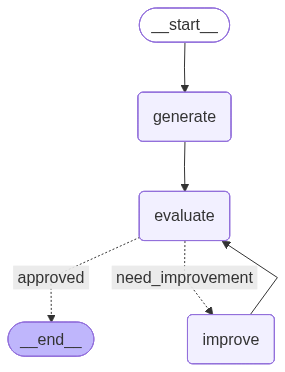

In [41]:
workflow

In [42]:
initial_state = {
    'topic': "Bihar road", 
    'iteration': 1,
    'max_iterations': 5
}

workflow.invoke(initial_state)

{'topic': 'Bihar road',
 'tweet': '"Bihar road: where the potholes are so deep, you need a map to find your way out of them. And the traffic? It\'s like a never-ending Bollywood dance party, minus the music and talent #BiharRoad #PotholeKingdom"',
 'evalution': 'approved',
 'feedback': "This tweet is well-crafted, with a clever play on words that effectively uses the concept of a 'Bollywood dance party' to describe the chaotic traffic on Bihar roads. The use of 'minus the music and talent' adds a layer of humor, making it more engaging and entertaining. However, the originality could be improved by making the comparison more unique and less predictable. Nevertheless, the tweet is well-formatted, concise, and has a good chance of going viral due to its relatability and humor.",
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['"Bihar road: where the potholes are so deep, you need a map to find your way out of them. And the traffic? It\'s like a never-ending Bollywood dance part